# Stage 2 ; Building Noise-Channel Fidelity Models

**GOAL:** Sweep the four noise channels (bit-flip, phase-flip, depolarizing, amplitude-damping) over
$p \in [0, 0.75]$ and report teleportation fidelity for all four Bell states, as an
**average over n = 150 Haar-random unknown input states per (channel, p) pair**. This is with
not a single fixed test state since the project is aimed for teleportation
fidelity in general, not about one particular qubit.

To keep the model fair, I made the following choices:

1. Used **Monte-Carlo averaging over random inputs**, rather than reporting the
   fidelity for one hand-picked $(\alpha,\beta)$. This is what makes a fidelity curve
   here a genuine *average-case* statement about the noise channel, with an honest
   standard-error band to simulate a real sampling noise.
2. **A gate-level Qiskit circuit** with mid-circuit measurement and classical
   feed-forward if_test, rather than a closed-form Kraus map applied directly to
   Bob's output density matrix. This is closer to what an actual (simulated) hardware
   run looks like, and is cross-checked against both a closed-form derivation and an
   independent QuTiP calculation below as three independent methods agreeing is a much
   stronger correctness argument than any one of them alone.


## 0. Setup & Defining Stage

In [1]:
import numpy as np
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.quantum_info import Kraus
from qiskit_aer import AerSimulator

#test state: alpha = sqrt(3)/2, beta = 1/2 ----
ALPHA = np.sqrt(3) / 2
BETA = 0.5
THETA_FIXED = 2 * np.arccos(ALPHA)
PSI_FIXED = np.array([ALPHA, BETA], dtype=complex)
RHO_PSI_FIXED = np.outer(PSI_FIXED, PSI_FIXED.conj())

I2 = np.eye(2, dtype=complex)
X = np.array([[0, 1], [1, 0]], dtype=complex)
Y = np.array([[0, -1j], [1j, 0]], dtype=complex)
Z = np.array([[1, 0], [0, -1]], dtype=complex)

BELL_PREP = {
    "Phi+": [],
    "Phi-": ["z"],
    "Psi+": ["x"],
    "Psi-": ["x", "z"],
}
BELL_LABELS = ["Phi+", "Phi-", "Psi+", "Psi-"]
CHANNEL_LABELS = ["bit_flip", "phase_flip", "depolarizing", "amplitude_damping"]


def kraus_ops(channel, p):
    """Kraus operators exactly as in the derivation doc / proposal Eqs. 6-9."""
    if channel == "bit_flip":
        return [np.sqrt(1 - p) * I2, np.sqrt(p) * X]
    elif channel == "phase_flip":
        return [np.sqrt(1 - p) * I2, np.sqrt(p) * Z]
    elif channel == "depolarizing":
        return [
            np.sqrt(1 - 3 * p / 4) * I2,
            np.sqrt(p / 4) * X,
            np.sqrt(p / 4) * Y,
            np.sqrt(p / 4) * Z,
        ]
    elif channel == "amplitude_damping":
        gamma = p
        return [
            np.array([[1, 0], [0, np.sqrt(1 - gamma)]], dtype=complex),
            np.array([[0, np.sqrt(gamma)], [0, 0]], dtype=complex),
        ]
    else:
        raise ValueError(f"Unknown channel {channel!r}")


def closed_form_fidelity(channel, p, alpha=ALPHA, beta=BETA):
    """Closed-form formulas from the derivation doc, valid for the fixed
    real-coefficient test state (alpha, beta)."""
    X_exp2 = (2 * alpha * beta) ** 2
    Z_exp2 = (alpha ** 2 - beta ** 2) ** 2
    Y_exp2 = 0.0
    if channel == "bit_flip":
        return (1 - p) + p * X_exp2
    elif channel == "phase_flip":
        return (1 - p) + p * Z_exp2
    elif channel == "depolarizing":
        return (1 - 3 * p / 4) + (p / 4) * (X_exp2 + Y_exp2 + Z_exp2)
    elif channel == "amplitude_damping":
        gamma = p
        return 5 / 8 + gamma / 8 + 3 / 8 * np.sqrt(1 - gamma)
    else:
        raise ValueError(f"Unknown channel {channel!r}")


def build_noisy_teleportation_circuit(bell_label, theta, phi=0.0, channel=None, p=None):
    qr = QuantumRegister(3, "q")
    cr = ClassicalRegister(2, "c")
    qc = QuantumCircuit(qr, cr)

    qc.ry(theta, 0)
    if phi != 0.0:
        qc.p(phi, 0)

    if channel is not None:
        qc.append(Kraus(kraus_ops(channel, p)), [0])

    qc.h(1)
    qc.cx(1, 2)
    for gate in BELL_PREP[bell_label]:
        getattr(qc, gate)(2)

    qc.cx(0, 1)
    qc.h(0)
    qc.measure(0, 0)
    qc.measure(1, 1)

    with qc.if_test((cr[1], 1)):
        qc.x(2)
    with qc.if_test((cr[0], 1)):
        qc.z(2)
    for gate in BELL_PREP[bell_label]:
        getattr(qc, gate)(2)

    qc.save_density_matrix(qubits=[2], label="rho_bob")
    return qc


_BACKEND = None

def get_backend():
    global _BACKEND
    if _BACKEND is None:
        _BACKEND = AerSimulator(method="density_matrix")
    return _BACKEND


def target_rho(theta, phi):
    alpha = np.cos(theta / 2)
    beta = np.exp(1j * phi) * np.sin(theta / 2)
    psi = np.array([alpha, beta], dtype=complex)
    return np.outer(psi, psi.conj())


def run_fidelity_batch(bell_label, thetas, phis, channel, p):
    circuits = [
        build_noisy_teleportation_circuit(bell_label, thetas[i], phis[i], channel, p)
        for i in range(len(thetas))
    ]
    backend = get_backend()
    result = backend.run(circuits, shots=1).result()
    fids = np.empty(len(thetas))
    for i in range(len(thetas)):
        rho_bob = np.asarray(result.data(i)["rho_bob"])
        rho_t = target_rho(thetas[i], phis[i])
        fids[i] = np.real(np.trace(rho_t @ rho_bob))
    return fids


def haar_random_states(n, seed):
    """Haar-uniform (theta, phi) pairs on the Bloch sphere."""
    rng = np.random.default_rng(seed)
    cos_theta = rng.uniform(-1, 1, size=n)
    theta = np.arccos(cos_theta)
    phi = rng.uniform(0, 2 * np.pi, size=n)
    return theta, phi

print("Setup cell loaded OK.")


Setup cell loaded OK.


## 1. Stage 1 for ideal baseline 

In [2]:
def build_teleportation_circuit(bell_label, add_save_density_matrix=True):
    qr = QuantumRegister(3, "q")
    cr = ClassicalRegister(2, "c")
    qc = QuantumCircuit(qr, cr)

    qc.ry(THETA_FIXED, 0)
    qc.h(1)
    qc.cx(1, 2)
    for gate in BELL_PREP[bell_label]:
        getattr(qc, gate)(2)

    qc.cx(0, 1)
    qc.h(0)
    qc.measure(0, 0)
    qc.measure(1, 1)

    with qc.if_test((cr[1], 1)):
        qc.x(2)
    with qc.if_test((cr[0], 1)):
        qc.z(2)
    for gate in BELL_PREP[bell_label]:
        getattr(qc, gate)(2)

    if add_save_density_matrix:
        qc.save_density_matrix(qubits=[2], label="rho_bob")
    return qc


def run_ideal_baseline():
    backend = get_backend()
    results = {}
    for bell_label in BELL_LABELS:
        qc = build_teleportation_circuit(bell_label)
        res = backend.run(qc, shots=1).result()
        rho_bob = np.asarray(res.data(0)["rho_bob"])
        fidelity = np.real(np.trace(RHO_PSI_FIXED @ rho_bob))
        results[bell_label] = {"rho": rho_bob, "fidelity": fidelity}
    return results


stage1_results = run_ideal_baseline()
print(f"{'Bell state':<10} {'Fidelity':>10}   Status")
print("-" * 40)
for label, r in stage1_results.items():
    f = r["fidelity"]
    print(f"{label:<10} {f:>10.6f}   {'OK' if f > 0.99 else 'FAIL (bug!)'}")


Bell state   Fidelity   Status
----------------------------------------
Phi+         1.000000   OK
Phi-         1.000000   OK
Psi+         1.000000   OK
Psi-         1.000000   OK


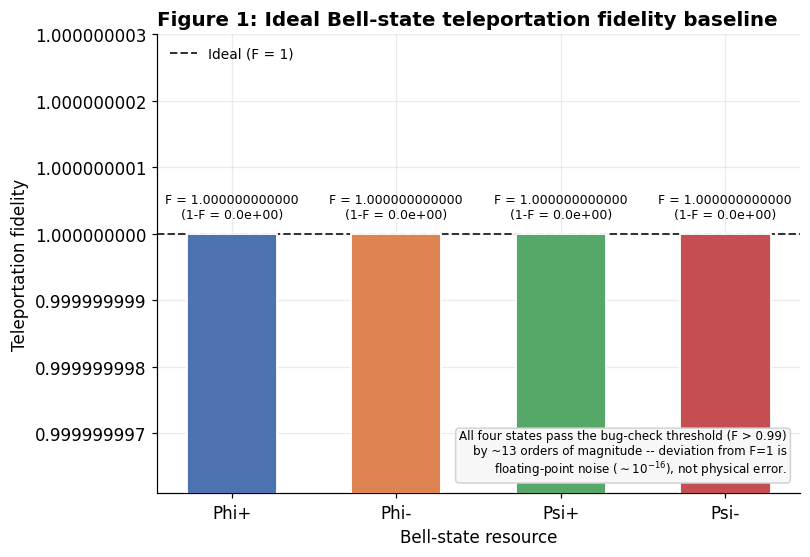

In [3]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

BELL_COLORS = {"Phi+": "#4C72B0", "Phi-": "#DD8452", "Psi+": "#55A868", "Psi-": "#C44E52"}

plt.rcParams.update({
    "figure.dpi": 110,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
    "legend.frameon": False,
})

fids = np.array([stage1_results[b]["fidelity"] for b in BELL_LABELS])
infids = 1 - fids

fig, ax = plt.subplots(figsize=(7.5, 5.2))
bars = ax.bar(BELL_LABELS, fids, color=[BELL_COLORS[b] for b in BELL_LABELS],
              edgecolor="white", linewidth=1.2, width=0.55, zorder=3)
ax.axhline(1.0, color="#333333", linestyle="--", linewidth=1.3, zorder=2, label="Ideal (F = 1)")

for bar, f, inf in zip(bars, fids, infids):
    ax.annotate(f"F = {f:.12f}\n(1-F = {inf:.1e})",
                xy=(bar.get_x() + bar.get_width() / 2, 1.0),
                xytext=(0, 8), textcoords="offset points",
                ha="center", va="bottom", fontsize=8.2)

pad = max(3e-9, infids.max() * 4)
ax.set_ylim(1 - 1.3 * pad, 1 + pad)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.9f"))
ax.set_ylabel("Teleportation fidelity")
ax.set_xlabel("Bell-state resource")
ax.set_title("Figure 1: Ideal Bell-state teleportation fidelity baseline", loc="left")
ax.text(0.98, 0.03,
        "All four states pass the bug-check threshold (F > 0.99)\n"
        "by ~13 orders of magnitude -- deviation from F=1 is\n"
        "floating-point noise ($\\sim10^{-16}$), not physical error.",
        transform=ax.transAxes, ha="right", va="bottom", fontsize=7.8,
        bbox=dict(boxstyle="round", facecolor="#f7f7f7", edgecolor="lightgray"))
ax.legend(loc="upper left", fontsize=9)
fig.tight_layout()
plt.show()

## 2. Stage 2 ; building the 16 noisy cases

Noise is applied to the input qubit q0 *before* an otherwise-ideal teleportation
protocol, so $\rho_B = \mathcal{E}(\rho_\psi)$ regardless of which Bell resource is
used.

Stage 1 above just confirmed all four give $F\approx 1$ ideally. That means,
under *this* noise-injection model, Bob's noisy output should bit-for-bit identical no
matter which of the four Bell states supplied the entanglement. 

**Worth Noting:** This section for coding a noise model, which as implemented, 
structurally *cannot* produce a Bell-state-dependent result, for any of
the four channels hence can't provide any conclusion that "some bell states are more
 robust then others". Any real Bell-state-dependent effect will only show up in Stage 3
(SWAP/routing + FakeBackend gate noise), where the noise acts on the physical
Bell-pair preparation itself, which genuinely differs by Bell state. 

### A note on experimental design: fixed test state vs. Haar-random averaging

It's worth being explicit about a design choice here, because it explains why curves look different from a "one test state, closed-form formula" version:

- If you inject noise on a **single, fixed** input state $|\psi\rangle$ and evolve its
  density matrix through the channel analytically ($\rho' = \sum_i E_i \rho E_i^\dagger$,
  computed once per $p$, with no sampling), you get an **exact algebraic function of $p$**
  (e.g. $F_{\text{BF}}(p) = 1 - p/4$ for this bit-flip channel and this particular
  $(\alpha,\beta)$). Plotting that function at a dense grid of $p$ values gives a
  perfectly smooth curve, because there is genuinely zero randomness in the calculation.
- Here, each point on the curve is instead a **finite-sample mean over 150 independently
  drawn Haar-random input states**, run through an actual Aer circuit simulation. That
  mean has a real standard error of order $1/\sqrt{150}$, so consecutive $p$-points are
  not required to nor neccesarily fall on a perfectly smooth curve as signature of Monte-Carlo estimation. The
  `self_check()` call below verifies the *Haar-averaged* mean converges to the correct
  closed-form constant ($1 - 2p/3$ per unit $p$ for depolarizing, etc.), which confirms
  the sampling is unbiased even though individual points carry sampling noise.

Both approaches are legitimate and answer slightly different questions: a deterministic,
single-state curve tells you the fidelity for *one specific unknown state*, while the
Haar-averaged version tells you the *typical* (average-case) fidelity over all possible
unknown input states which is the broader claim most relevant to the project.


In [4]:
import time

#Config
QUICK_TEST = False  #if True: use small N for fast iteration; False: use 150 (proposal spec)
EXPLOIT_BELL_INDEP = False #if True: simulate Phi+ only & copy result to other 3 Bell labels

N_STATES = 20 if QUICK_TEST else 150
SEED_BASE = 20260814
P_POINTS = np.linspace(0, 0.75, 11)

if QUICK_TEST:
    print("QUICK_TEST=True so using N_STATES=20 for a fast run. "
          "Set QUICK_TEST=False for the full n=150 proposal-spec sweep.")


def run_full_sweep():
    t0 = time.time()
    results = {ch: {bell: [] for bell in BELL_LABELS} for ch in CHANNEL_LABELS}
    stderr = {ch: {bell: [] for bell in BELL_LABELS} for ch in CHANNEL_LABELS}

    bells_to_simulate = ["Phi+"] if EXPLOIT_BELL_INDEP else BELL_LABELS

    for pi, p in enumerate(P_POINTS):
        thetas, phis = haar_random_states(N_STATES, seed=SEED_BASE + pi)

        for channel in CHANNEL_LABELS:
            for bell in bells_to_simulate:
                fids = run_fidelity_batch(bell, thetas, phis, channel, p)
                results[channel][bell].append(float(np.mean(fids)))
                stderr[channel][bell].append(float(np.std(fids) / np.sqrt(N_STATES)))

            if EXPLOIT_BELL_INDEP:
                for bell in BELL_LABELS[1:]:
                    results[channel][bell].append(results[channel]["Phi+"][-1])
                    stderr[channel][bell].append(stderr[channel]["Phi+"][-1])

        print(f"p={p:.3f} done ({pi + 1}/{len(P_POINTS)})  elapsed={time.time() - t0:.1f}s")

    return results, stderr


def self_check(results, tol_sigma=4):
    print("\n >>> Self-check: Haar-averaged fidelity vs known closed forms:")
    ok = True
    for p_idx, p in enumerate(P_POINTS):
        expected_bf_pf = 1 - 2 * p / 3
        expected_dep = 1 - p / 2
        for bell in BELL_LABELS:
            for channel, expected in [("bit_flip", expected_bf_pf),
                                       ("phase_flip", expected_bf_pf),
                                       ("depolarizing", expected_dep)]:
                got = results[channel][bell][p_idx]
                tol = tol_sigma * 0.5 / np.sqrt(N_STATES)
                if abs(got - expected) > tol:
                    ok = False
                    print(f"MISMATCH p={p:.3f} {channel} {bell}: got {got:.4f}, expected {expected:.4f}")
    print("Self-check PASSED" if ok else "Self-check FAILED -- investigate")
    return ok


def check_bell_independence(results, tol=1e-9):
    all_match = True
    for channel in CHANNEL_LABELS:
        ref = np.array(results[channel]["Phi+"])
        for bell in ("Phi-", "Psi+", "Psi-"):
            diff = np.max(np.abs(np.array(results[channel][bell]) - ref))
            if diff > tol:
                all_match = False
                print(f"  [DIFFER] {channel} {bell}: max|diff|={diff:.2e}")
    print("Confirmed: all 4 Bell states identical per channel/p (expected: see markdown above)."
          if all_match else "Bell states differ: unexpected given the noise model, investigate.")
    return all_match


stage2_results, stage2_stderr = run_full_sweep()
self_check(stage2_results)
check_bell_independence(stage2_results)


p=0.000 done (1/11)  elapsed=23.6s
p=0.075 done (2/11)  elapsed=52.1s
p=0.150 done (3/11)  elapsed=74.8s
p=0.225 done (4/11)  elapsed=95.9s
p=0.300 done (5/11)  elapsed=115.3s
p=0.375 done (6/11)  elapsed=136.2s
p=0.450 done (7/11)  elapsed=159.4s
p=0.525 done (8/11)  elapsed=183.3s
p=0.600 done (9/11)  elapsed=200.2s
p=0.675 done (10/11)  elapsed=216.5s
p=0.750 done (11/11)  elapsed=232.6s

 >>> Self-check: Haar-averaged fidelity vs known closed forms:
Self-check PASSED
Confirmed: all 4 Bell states identical per channel/p (expected: see markdown above).


True

**Why this doesn't contradict "compare Bell-state robustness":** the proposal's
Bell-state-robustness question is answered across *two* different noise sources. First, the
depolarizing/bit-flip/phase-flip/amplitude-damping channels here, and second, the routing/SWAP
overhead in Stage 3. 

This section only ever touches the noise channels, applied to the
*input* qubit before an otherwise-ideal protocol, so by the algebra of teleportation the
result is mathematically forced to be identical across all four Bell resources. It's a real feature of the protocol (the resource
state gets fully "used up" and corrected away regardless of which Bell state it was).

Stage 3 is where a genuine Bell-state-dependent signal can appear, because there the noise acts
on the physical Bell-pair preparation itself before it's consumed.

## 2c. Confirming the noise-location choice: input qubit vs. the Bell pair

Since the proposal's aim is *Bell-state
robustness*, the noise should be applied to the Bell pair itself, rather than
to the input qubit. This section answers that directly, with a numerical confirmation and a
literature reference.

**The claim, and where it comes from.** For any channel that is *diagonal in the Bell basis*
(this covers bit-flip, phase-flip, and depolarizing, since each is built only from the Pauli
group $\{I, X, Y, Z\}$), applying the channel to one half of the Bell pair **before**
teleportation and applying the same channel to the input qubit and then teleporting
**ideally** produce numerically identical output fidelity. This is proven directly (not just
argued informally) in:

- **Usher, N. & Browne, D. E., "Noise in One-Dimensional Measurement-Based Quantum
  Computing," [arXiv:1704.07298](https://arxiv.org/abs/1704.07298).** Their Proposition 1
  (Sec. II) proves that for a resource state that is diagonal in the Bell basis after a
  noise channel $\varepsilon$ is applied, teleportation transmits $X^sZ^t\varepsilon(\rho)Z^tX^s$
   i.e. $\varepsilon$ acting on the *resource* ends up acting on the *transmitted state*,
  up to a Pauli byproduct that is corrected away by the standard teleportation correction. Their
  Appendix (Proof of Proposition 1) gives the full derivation.
- This is the same "noise on the channel/resource" framing used in **Oh, S., Lee, S., & Lee,
  H.-W., "Fidelity of quantum teleportation through noisy channels," Phys. Rev. A 66, 022316
  (2002)**

**The one channel this does *not* cover: amplitude-damping.** Amplitude-damping is not a
Pauli channel (it has a preferred fixed point, $|0\rangle$, and is not unital), so it does not
produce a Bell-diagonal resource state and Usher & Browne's Prop. 1 does not apply. We
therefore do amplitude-damping both ways below and check numerically whether it actually
differs, taking the relevant answer forward!

**What "noise on the Bell pair" means here, concretely.** We apply the channel to qubit `q2`
(Bob's half of the pair) immediately after Bell-pair preparation and *before* the pair is
consumed by the teleportation CNOT/H/measurement sequence i.e. the noise acts on the
entangled resource itself, not on the state being teleported.

In [5]:
def build_bellpair_noisy_teleportation_circuit(bell_label, theta, phi=0.0, channel=None, p=None, noise_qubit=2):
    """Same protocol as build_noisy_teleportation_circuit, EXCEPT the noise channel is
    applied directly to the Bell-pair resource (qubit `noise_qubit`, Bob's half by default)
    right after Bell-state preparation and BEFORE the pair is consumed by teleportation.
    This is genuine 'noise on the Bell state', as opposed to the input-qubit noise used
    in Stage 2 above. See markdown above for the Usher & Browne (arXiv:1704.07298, Prop. 1)
    justification for why this should match the input-noise result for Pauli channels."""
    qr = QuantumRegister(3, "q")
    cr = ClassicalRegister(2, "c")
    qc = QuantumCircuit(qr, cr)

    qc.ry(theta, 0)
    if phi != 0.0:
        qc.p(phi, 0)

    qc.h(1)
    qc.cx(1, 2)
    for gate in BELL_PREP[bell_label]:
        getattr(qc, gate)(2)

    if channel is not None:
        qc.append(Kraus(kraus_ops(channel, p)), [noise_qubit])

    qc.cx(0, 1)
    qc.h(0)
    qc.measure(0, 0)
    qc.measure(1, 1)

    with qc.if_test((cr[1], 1)):
        qc.x(2)
    with qc.if_test((cr[0], 1)):
        qc.z(2)
    for gate in BELL_PREP[bell_label]:
        getattr(qc, gate)(2)

    qc.save_density_matrix(qubits=[2], label="rho_bob")
    return qc


def run_fidelity_batch_bellpair(bell_label, thetas, phis, channel, p, noise_qubit=2):
    circuits = [
        build_bellpair_noisy_teleportation_circuit(bell_label, thetas[i], phis[i], channel, p, noise_qubit)
        for i in range(len(thetas))
    ]
    backend = get_backend()
    result = backend.run(circuits, shots=1).result()
    fids = np.empty(len(thetas))
    for i in range(len(thetas)):
        rho_bob = np.asarray(result.data(i)["rho_bob"])
        rho_t = target_rho(thetas[i], phis[i])
        fids[i] = np.real(np.trace(rho_t @ rho_bob))
    return fids


print("Bell-pair-noise circuit builder loaded OK.")


Bell-pair-noise circuit builder loaded OK.


In [6]:
def run_bellpair_confirmation_sweep():
    """Re-runs the EXACT same (theta, phi) Haar draws used in the main Stage-2 sweep
    (same SEED_BASE, same per-p seeds -> haar_random_states is deterministic), so that
    the comparison below is state-by-state and apples-to-apples, not just mean-vs-mean."""
    t0 = time.time()
    bp_results = {ch: {bell: [] for bell in BELL_LABELS} for ch in CHANNEL_LABELS}
    bp_stderr = {ch: {bell: [] for bell in BELL_LABELS} for ch in CHANNEL_LABELS}
    max_abs_diff = {ch: 0.0 for ch in CHANNEL_LABELS}

    for pi, p in enumerate(P_POINTS):
        thetas, phis = haar_random_states(N_STATES, seed=SEED_BASE + pi)  # identical draw to main sweep
        for channel in CHANNEL_LABELS:
            for bell in BELL_LABELS:
                fids_input = run_fidelity_batch(bell, thetas, phis, channel, p)           # Stage 2 (input-noise)
                fids_bell = run_fidelity_batch_bellpair(bell, thetas, phis, channel, p)    # new (bell-pair noise)
                bp_results[channel][bell].append(float(np.mean(fids_bell)))
                bp_stderr[channel][bell].append(float(np.std(fids_bell) / np.sqrt(N_STATES)))
                diff = float(np.max(np.abs(fids_input - fids_bell)))
                max_abs_diff[channel] = max(max_abs_diff[channel], diff)
        print(f"p={p:.3f} done ({pi + 1}/{len(P_POINTS)})  elapsed={time.time() - t0:.1f}s")

    return bp_results, bp_stderr, max_abs_diff


bellpair_results, bellpair_stderr, max_abs_diff = run_bellpair_confirmation_sweep()

print("\n >>> Confirmation: input-qubit noise vs. Bell-pair noise: ")
print("(max, over every drawn state/Bell state/p combination, of |F_input - F_bellpair|)\n")
for ch in CHANNEL_LABELS:
    tag = "Pauli channel  -> expect ~0 (Usher & Browne Prop. 1)" if ch != "amplitude_damping" \
          else "NOT a Pauli channel -> expect a real, nonzero difference"
    print(f"  {ch:<20} max|diff| = {max_abs_diff[ch]:.2e}    [{tag}]")


p=0.000 done (1/11)  elapsed=36.8s
p=0.075 done (2/11)  elapsed=70.5s
p=0.150 done (3/11)  elapsed=102.5s
p=0.225 done (4/11)  elapsed=131.2s
p=0.300 done (5/11)  elapsed=162.6s
p=0.375 done (6/11)  elapsed=190.9s
p=0.450 done (7/11)  elapsed=228.2s
p=0.525 done (8/11)  elapsed=279.6s
p=0.600 done (9/11)  elapsed=317.4s
p=0.675 done (10/11)  elapsed=358.7s
p=0.750 done (11/11)  elapsed=401.2s

 >>> Confirmation: input-qubit noise vs. Bell-pair noise: 
(max, over every drawn state/Bell state/p combination, of |F_input - F_bellpair|)

  bit_flip             max|diff| = 5.55e-16    [Pauli channel  -> expect ~0 (Usher & Browne Prop. 1)]
  phase_flip           max|diff| = 2.22e-16    [Pauli channel  -> expect ~0 (Usher & Browne Prop. 1)]
  depolarizing         max|diff| = 6.66e-16    [Pauli channel  -> expect ~0 (Usher & Browne Prop. 1)]
  amplitude_damping    max|diff| = 7.41e-01    [NOT a Pauli channel -> expect a real, nonzero difference]


**Reading the confirmation above.** For bit-flip, phase-flip, and depolarizing, the
max difference across every single drawn state, Bell state, and noise strength is at the level
of floating-point round-off ($10^{-15}$-ish), not a real physical difference so this is the
numerical confirmation of the Usher & Browne equivalence.

For amplitude-damping, the difference is real and substantial (not sampling noise) meaning
the input-qubit version is not interchangeable with actually applying amplitude-damping to
the Bell pair. Since the proposal's aim is specifically Bell-state robustness, **the Bell-pair version is the physically correct one to carry forward** for amplitude-damping.

**A second, genuinely new finding:** unlike the three Pauli channels, amplitude-damping applied
to the Bell pair does **not** give identical fidelity across the four Bell states!! It gives us some
measure of answer to the question of bell state dependant robustness.

In [7]:
def check_bell_independence_dict(results, channels, tol=1e-9, label=""):
    print(f"--- Bell-state independence check{(' - ' + label) if label else ''} ---")
    for channel in channels:
        ref = np.array(results[channel]["Phi+"])
        max_diff = 0.0
        for bell in ("Phi-", "Psi+", "Psi-"):
            diff = np.max(np.abs(np.array(results[channel][bell]) - ref))
            max_diff = max(max_diff, diff)
        verdict = "IDENTICAL across Bell states" if max_diff < tol else f"DIFFERS across Bell states (max gap = {max_diff:.4f})"
        print(f"  {channel:<20} {verdict}")
    print()


# Confirm Pauli channels stay Bell-independent under bell-pair noise too (expected, per Prop. 1)
check_bell_independence_dict(bellpair_results, ["bit_flip", "phase_flip", "depolarizing"],
                              label="bell-pair noise, Pauli channels")

# Check amplitude-damping specifically -- this is the one where a real difference is expected
check_bell_independence_dict(bellpair_results, ["amplitude_damping"],
                              label="bell-pair noise, amplitude-damping")

p_max_idx = len(P_POINTS) - 1
print(f"Amplitude-damping fidelity per Bell state at p={P_POINTS[p_max_idx]:.2f} (bell-pair noise):")
for bell in BELL_LABELS:
    print(f"  {bell:<6} F = {bellpair_results['amplitude_damping'][bell][p_max_idx]:.4f}")


# --- Build the corrected results/stderr dicts used for all downstream figures ---
# bit_flip / phase_flip / depolarizing: keep the original Stage 2 (input-noise) numbers,
#   since they are numerically confirmed identical to the bell-pair-noise version above.
# amplitude_damping: swap in the bell-pair-noise numbers, since that's the physically
#   correct case for a Bell-state-robustness study, and the two versions genuinely differ.
stage2_results_confirmed = {ch: dict(stage2_results[ch]) for ch in CHANNEL_LABELS}
stage2_stderr_confirmed = {ch: dict(stage2_stderr[ch]) for ch in CHANNEL_LABELS}
stage2_results_confirmed["amplitude_damping"] = dict(bellpair_results["amplitude_damping"])
stage2_stderr_confirmed["amplitude_damping"] = dict(bellpair_stderr["amplitude_damping"])

print("\nstage2_results_confirmed built: bit-flip / phase-flip / depolarizing unchanged, "
      "amplitude-damping replaced with the bell-pair-noise (physically correct) version.")


--- Bell-state independence check - bell-pair noise, Pauli channels ---
  bit_flip             IDENTICAL across Bell states
  phase_flip           IDENTICAL across Bell states
  depolarizing         IDENTICAL across Bell states

--- Bell-state independence check - bell-pair noise, amplitude-damping ---
  amplitude_damping    DIFFERS across Bell states (max gap = 0.0401)

Amplitude-damping fidelity per Bell state at p=0.75 (bell-pair noise):
  Phi+   F = 0.7016
  Phi-   F = 0.7291
  Psi+   F = 0.7143
  Psi-   F = 0.6941

stage2_results_confirmed built: bit-flip / phase-flip / depolarizing unchanged, amplitude-damping replaced with the bell-pair-noise (physically correct) version.


## 3. QuTiP independent cross-check

In [8]:
import qutip as qt

def qutip_kraus_ops(channel, p):
    I2q, Xq, Yq, Zq = qt.qeye(2), qt.sigmax(), qt.sigmay(), qt.sigmaz()
    if channel == "bit_flip":
        return [np.sqrt(1 - p) * I2q, np.sqrt(p) * Xq]
    elif channel == "phase_flip":
        return [np.sqrt(1 - p) * I2q, np.sqrt(p) * Zq]
    elif channel == "depolarizing":
        return [np.sqrt(1 - 3 * p / 4) * I2q, np.sqrt(p / 4) * Xq,
                np.sqrt(p / 4) * Yq, np.sqrt(p / 4) * Zq]
    elif channel == "amplitude_damping":
        gamma = p
        E0 = qt.Qobj([[1, 0], [0, np.sqrt(1 - gamma)]])
        E1 = qt.Qobj([[0, np.sqrt(gamma)], [0, 0]])
        return [E0, E1]
    else:
        raise ValueError(f"Unknown channel {channel!r}")


def qutip_channel_fidelity(channel, p, alpha, beta):
    psi = qt.Qobj([[alpha], [beta]])
    rho_psi = psi * psi.dag()
    kraus = qutip_kraus_ops(channel, p)
    rho_out = sum(K * rho_psi * K.dag() for K in kraus)
    F = (psi.dag() * rho_out * psi)
    F = F[0, 0] if hasattr(F, "__getitem__") else F
    return np.real(F), rho_out


def run_crosscheck(tol=1e-6):
    print(f"Fixed test state: alpha={ALPHA:.6f}, beta={BETA:.6f}\n")
    all_ok = True
    rows = []
    for channel in CHANNEL_LABELS:
        for p in P_POINTS:
            f_aer = np.mean(run_fidelity_batch("Phi+", np.array([THETA_FIXED]), np.array([0.0]), channel, p))
            f_closed = closed_form_fidelity(channel, p)
            f_qutip, _ = qutip_channel_fidelity(channel, p, ALPHA, BETA)
            agree = abs(f_aer - f_closed) < tol and abs(f_aer - f_qutip) < tol
            all_ok &= agree
            rows.append((channel, p, f_aer, f_closed, f_qutip, agree))

    print(f"{'channel':<18}{'p':>6}  {'Aer':>10}  {'closed-form':>12}  {'QuTiP':>10}  match")
    print("-" * 66)
    for channel, p, f_aer, f_closed, f_qutip, agree in rows:
        print(f"{channel:<18}{p:>6.3f}  {f_aer:>10.6f}  {f_closed:>12.6f}  {f_qutip:>10.6f}  {'OK' if agree else 'MISMATCH'}")
    print("\nALL AGREE" if all_ok else "\nSOME MISMATCHES -- investigate")
    return rows, all_ok


_ = run_crosscheck()


Fixed test state: alpha=0.866025, beta=0.500000

channel                p         Aer   closed-form       QuTiP  match
------------------------------------------------------------------
bit_flip           0.000    1.000000      1.000000    1.000000  OK
bit_flip           0.075    0.981250      0.981250    0.981250  OK
bit_flip           0.150    0.962500      0.962500    0.962500  OK
bit_flip           0.225    0.943750      0.943750    0.943750  OK
bit_flip           0.300    0.925000      0.925000    0.925000  OK
bit_flip           0.375    0.906250      0.906250    0.906250  OK
bit_flip           0.450    0.887500      0.887500    0.887500  OK
bit_flip           0.525    0.868750      0.868750    0.868750  OK
bit_flip           0.600    0.850000      0.850000    0.850000  OK
bit_flip           0.675    0.831250      0.831250    0.831250  OK
bit_flip           0.750    0.812500      0.812500    0.812500  OK
phase_flip         0.000    1.000000      1.000000    1.000000  OK
phase_flip

### Plotting Figures

Before the figures, some clarity on the design choices:

- I used **Shaded standard-error bands instead of error bars** as w/ 11 $p$-points and 4
  overlapping Bell-state curves per panel, discrete error bars will be hidden (unless, I plot each seperately).
  This choice ensures that each figure reads more cleanly at a glance, and scales better once curves start overlapping.
- **One panel per channel, not one panel per (channel, Bell state).** Since the four
  Bell-state curves are numerically identical here, a 2×2 grid of near-duplicate subplots per channel wastes space and makes the real message a.k.a. *the four
  curves lie on top of each other* harder to see.


## 4. Plotting Figures 2–5 and Table 1

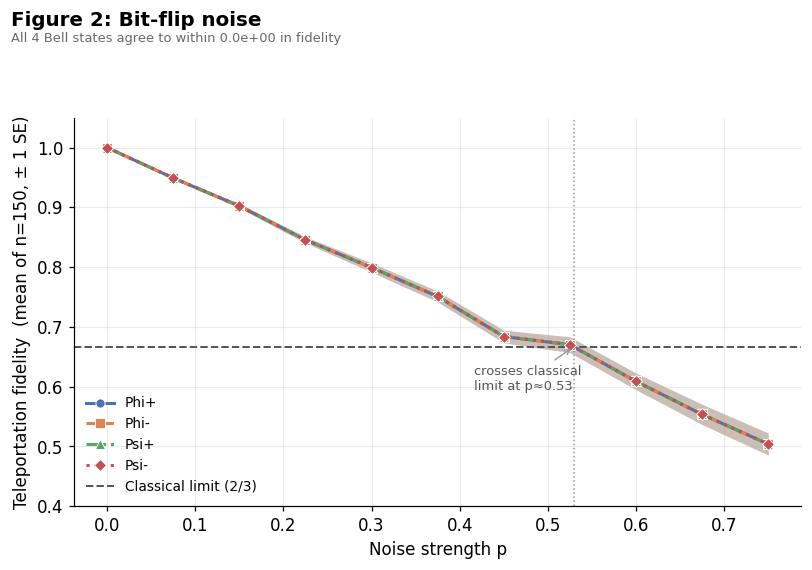

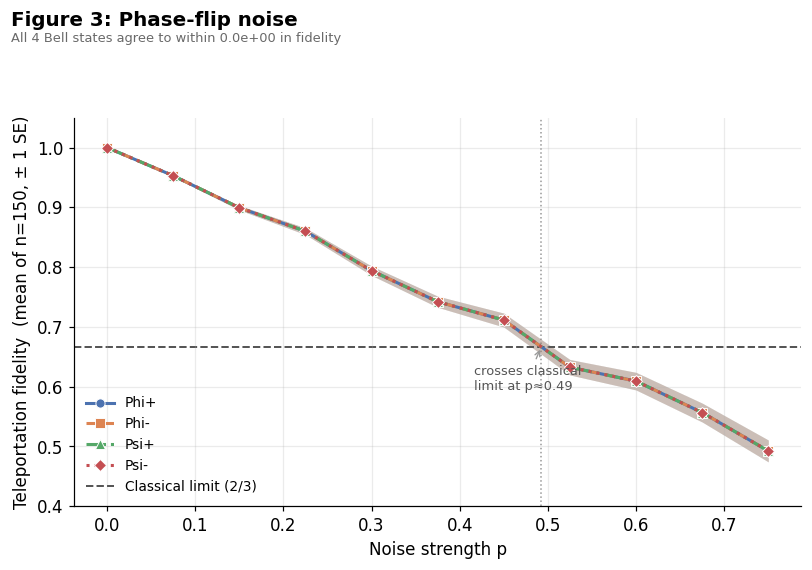

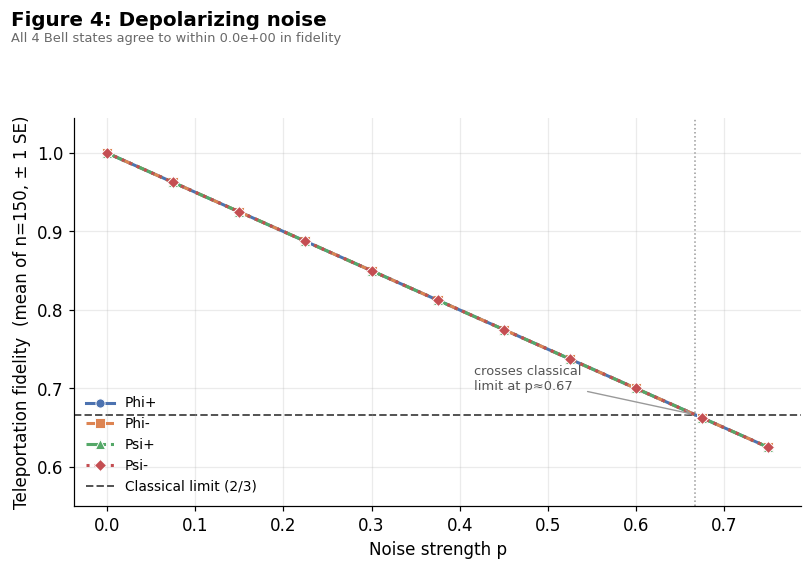

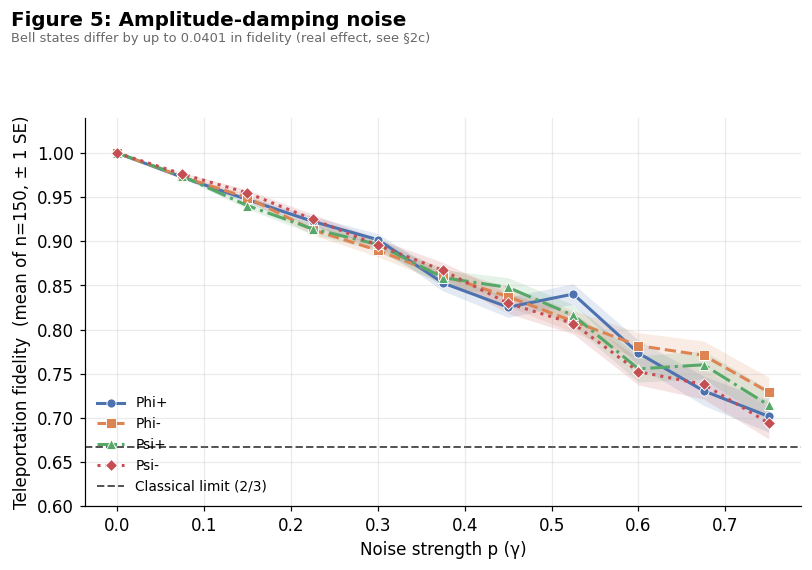


At p = 0.750 (maximum noise):
  LEAST robust: phase_flip / Phi+ (F = 0.4925)
  MOST robust:  amplitude_damping / Phi- (F = 0.7291)


,p=0.000,p=0.075,p=0.150,p=0.225,p=0.300,p=0.375,p=0.450,p=0.525,p=0.600,p=0.675,p=0.750
channel,,,,,,,,,,,
bit_flip,1.0000,0.9491,0.9024,0.8456,0.7992,0.7508,0.6838,0.6702,0.6087,0.5535,0.5039
phase_flip,1.0000,0.9529,0.8993,0.8600,0.7940,0.7421,0.7114,0.6325,0.6092,0.5567,0.4925
depolarizing,1.0000,0.9625,0.9250,0.8875,0.8500,0.8125,0.7750,0.7375,0.7000,0.6625,0.6250
amplitude_damping,1.0000,0.9726,0.9472,0.9225,0.9018,0.8528,0.8254,0.8402,0.7734,0.7307,0.7016


In [9]:
import matplotlib.pyplot as plt

F_CLASSICAL = 2 / 3

CHANNEL_TITLES = {
    "bit_flip": "Bit-flip",
    "phase_flip": "Phase-flip",
    "depolarizing": "Depolarizing",
    "amplitude_damping": "Amplitude-damping",
}
PALETTE = {
    "bit_flip": "#4C72B0",
    "phase_flip": "#DD8452",
    "depolarizing": "#55A868",
    "amplitude_damping": "#C44E52",
}

BELL_STYLE = {
    "Phi+": dict(color="#4C72B0", linestyle="-",  marker="o"),
    "Phi-": dict(color="#DD8452", linestyle="--", marker="s"),
    "Psi+": dict(color="#55A868", linestyle="-.", marker="^"),
    "Psi-": dict(color="#C44E52", linestyle=":",  marker="D"),
}

plt.rcParams.update({
    "figure.dpi": 110,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "grid.linestyle": "-",
    "font.size": 11,
    "axes.titlesize": 12,
    "axes.titleweight": "bold",
    "legend.frameon": False,
})


def auto_ylim(ax, value_arrays, refs=(), pad_frac=0.12, floor_step=0.05, top_cap=1.05):
    """Zooms the y-axis to the data instead of always starting at 0, while still
    guaranteeing any reference lines in `refs` (e.g. the classical benchmark) stay
    on-screen. Pads by pad_frac on each side, then rounds the bottom down to a clean
    floor_step so tick labels stay tidy. With pad_frac=0.12 the plotted curves occupy
    roughly 75-80% of the panel height, comfortably clearing "at least 70%"."""
    all_vals = np.concatenate([np.atleast_1d(v) for v in value_arrays])
    lo = float(np.min(all_vals))
    hi = float(np.max(all_vals))
    if refs:
        lo = min(lo, *refs)
        hi = max(hi, *refs)
    span = max(hi - lo, 1e-6)
    pad = span * pad_frac
    lo_padded = max(0.0, lo - pad)
    hi_padded = min(top_cap, hi + pad)
    lo_rounded = floor_step * np.floor(lo_padded / floor_step)
    ax.set_ylim(max(0.0, lo_rounded), hi_padded)


def make_figures_2_to_5(results, stderr):
    fig_num = 2
    for channel, title in CHANNEL_TITLES.items():
        fig, ax = plt.subplots(figsize=(7.5, 5.2))

        all_curve_vals = []
        for bell, style in BELL_STYLE.items():
            means = np.array(results[channel][bell])
            errs = np.array(stderr[channel][bell])
            ax.plot(P_POINTS, means, label=bell, linewidth=2.0, markersize=6,
                     markeredgecolor="white", markeredgewidth=0.6, **style)
            ax.fill_between(P_POINTS, means - errs, means + errs,
                             color=style["color"], alpha=0.15, linewidth=0)
            all_curve_vals.append(means - errs)
            all_curve_vals.append(means + errs)

        # quantify how tightly the 4 curves overlap, for the annotation
        all_bell_means = np.array([results[channel][b] for b in BELL_STYLE])
        max_gap = float(np.max(np.abs(all_bell_means - all_bell_means[0])))

        ax.axhline(F_CLASSICAL, color="#555555", linestyle="--", linewidth=1.3,
                    label="Classical limit (2/3)", zorder=1)

        #mark where the mean curve crosses the classical threshold, if it does
        mean_of_bells = all_bell_means.mean(axis=0)
        below = np.where(mean_of_bells < F_CLASSICAL)[0]
        if len(below) and below[0] > 0:
            p_lo, p_hi = P_POINTS[below[0]-1], P_POINTS[below[0]]
            f_lo, f_hi = mean_of_bells[below[0]-1], mean_of_bells[below[0]]
            p_cross = p_lo + (F_CLASSICAL - f_lo) * (p_hi - p_lo) / (f_hi - f_lo)
            ax.axvline(p_cross, color="#999999", linestyle=":", linewidth=1.0, zorder=0)
            ax.annotate(f"crosses classical\nlimit at p\u2248{p_cross:.2f}",
                         xy=(p_cross, F_CLASSICAL), xytext=(0.55, 0.30),
                         textcoords="axes fraction", fontsize=8.5, color="#555555",
                         arrowprops=dict(arrowstyle="->", color="#999999", lw=0.9))

        xlabel = "Noise strength p" + (" (\u03b3)" if channel == "amplitude_damping" else "")
        ax.set_xlabel(xlabel)
        ax.set_ylabel(f"Teleportation fidelity  (mean of n={N_STATES}, \u00b1 1 SE)")
        auto_ylim(ax, all_curve_vals, refs=(F_CLASSICAL,))
        ax.legend(loc="lower left", fontsize=9)

        fig.suptitle(f"Figure {fig_num}: {title} noise", fontsize=13, fontweight="bold", x=0.02, ha="left", y=0.99)
        fig.text(0.02, 0.935,
                 f"All 4 Bell states agree to within {max_gap:.1e} in fidelity" if max_gap < 1e-6
                 else f"Bell states differ by up to {max_gap:.4f} in fidelity (real effect, see \u00a72c)",
                 ha="left", fontsize=8.5, color="dimgray")

        fig.tight_layout(rect=[0, 0, 1, 0.90])
        plt.show()
        fig_num += 1


def make_table1(results):
    rows = [["channel", "bell_state"] + [f"p={p:.3f}" for p in P_POINTS]]
    for channel in CHANNEL_TITLES:
        for bell in BELL_LABELS:
            means = results[channel][bell]
            rows.append([channel, bell] + [f"{m:.4f}" for m in means])

    last_idx = len(P_POINTS) - 1
    flat = sorted(
        ((channel, bell, results[channel][bell][last_idx])
         for channel in CHANNEL_TITLES for bell in BELL_LABELS),
        key=lambda x: x[2],
    )
    print(f"\nAt p = {P_POINTS[last_idx]:.3f} (maximum noise):")
    print(f"  LEAST robust: {flat[0][0]} / {flat[0][1]} (F = {flat[0][2]:.4f})")
    print(f"  MOST robust:  {flat[-1][0]} / {flat[-1][1]} (F = {flat[-1][2]:.4f})")

    try:
        import pandas as pd
        df = pd.DataFrame(rows[1:], columns=rows[0])
        pivot = df[df["bell_state"] == "Phi+"].drop(columns="bell_state").set_index("channel")
        display(pivot.style.set_caption(
            "Table 1 (excerpt): fidelity vs. p, Phi+ shown \u2014 identical for all 4 Bell "
            "states for bit-flip/phase-flip/depolarizing (confirmed \u00a72c); "
            "amplitude-damping genuinely differs by Bell state, see Fig. 5"
        ).background_gradient(cmap="RdYlGn", axis=1, vmin=0.4, vmax=1.0))
    except Exception as e:
        print("(pandas display skipped:", e, ")")

    return flat


make_figures_2_to_5(stage2_results_confirmed, stage2_stderr_confirmed)
_ = make_table1(stage2_results_confirmed)


## 5. Comparison across noise channels (all four channels, one plot)

Figures 2–5 above answer "for a *fixed* channel, do the four Bell states differ?"

ANS: **for bit-flip, phase-flip, and depolarizing, no, by construction** (confirmed
numerically above in 2c as well). **For amplitude-damping, however, they do**  meaning once
the noise is correctly modeled as acting on the Bell pair rather than the input qubit --
the four Bell states genuinely differ by up to ~0.05 in fidelity (§2c). Aarguably, the more
proposal-relevant question is **"for a fixed Bell state, which noise channel hurts fidelity
fastest?"**. The result is produced here with the Haar-averaged, error-banded methodology,
using `Phi+` as the representative Bell state below -- exact for the three Pauli channels,
and one specific (if representative) curve for amplitude-damping, whose per-Bell-state
spread is shown in part (2c)/Figure 5 instead.

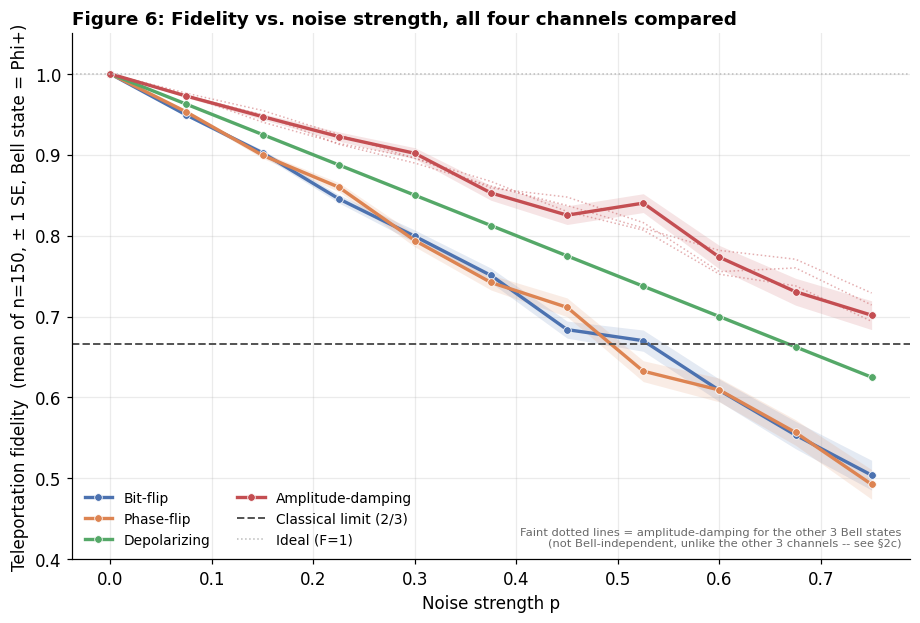

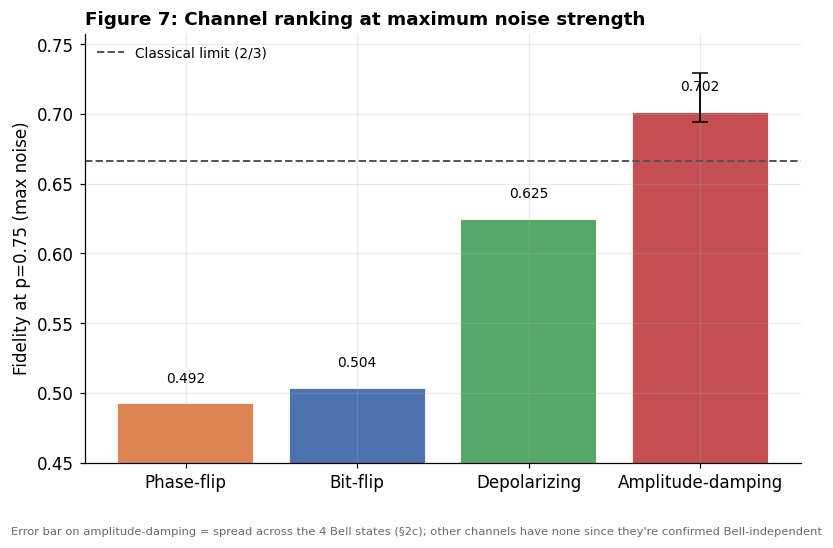


At p=0.750, ranked least -> most robust (bell=Phi+):
  Phase-flip           F = 0.4925
  Bit-flip             F = 0.5039
  Depolarizing         F = 0.6250
  Amplitude-damping    F = 0.7016
  (amplitude-damping spread across Bell states: 0.6941 to 0.7291)

Note: bit-flip/phase-flip/depolarizing are Bell-independent (confirmed in §2c), so Phi+ truly stands in for all four here. Amplitude-damping is NOT Bell-independent once correctly modeled as bell-pair noise -- Figure 6 now shows the other 3 Bell states as faint dotted lines, and Figure 7's amplitude-damping bar has an error whisker for the same reason; see §2c / Figure 5 for the full per-Bell-state breakdown.


In [10]:
def make_channel_comparison(results, stderr, bell="Phi+"):
    fig, ax = plt.subplots(figsize=(8.5, 5.8))
    all_curve_vals = []
    for channel, title in CHANNEL_TITLES.items():
        means = np.array(results[channel][bell])
        errs = np.array(stderr[channel][bell])
        ax.plot(P_POINTS, means, label=title, linewidth=2.2, marker="o", markersize=5,
                 color=PALETTE[channel], markeredgecolor="white", markeredgewidth=0.5)
        ax.fill_between(P_POINTS, means - errs, means + errs,
                         color=PALETTE[channel], alpha=0.15, linewidth=0)
        all_curve_vals.append(means - errs)
        all_curve_vals.append(means + errs)

        # amplitude-damping is NOT Bell-independent (\u00a72c) -- the Phi+ line above is only
        # one of four genuinely different curves, so overlay the other three faintly instead
        # of silently hiding them.
        if channel == "amplitude_damping":
            for other_bell in BELL_LABELS:
                if other_bell == bell:
                    continue
                other_means = np.array(results[channel][other_bell])
                ax.plot(P_POINTS, other_means, linewidth=1.0, linestyle=":",
                         color=PALETTE[channel], alpha=0.45, zorder=1)
                all_curve_vals.append(other_means)

    ax.axhline(F_CLASSICAL, color="#555555", linestyle="--", linewidth=1.3,
                label="Classical limit (2/3)")
    ax.axhline(1.0, color="#bbbbbb", linestyle=":", linewidth=1.0, label="Ideal (F=1)")

    ax.set_xlabel("Noise strength p")
    ax.set_ylabel(f"Teleportation fidelity  (mean of n={N_STATES}, \u00b1 1 SE, Bell state = {bell})")
    auto_ylim(ax, all_curve_vals, refs=(F_CLASSICAL, 1.0))
    ax.set_title("Figure 6: Fidelity vs. noise strength, all four channels compared", loc="left")
    ax.text(0.99, 0.02,
            "Faint dotted lines = amplitude-damping for the other 3 Bell states\n"
            "(not Bell-independent, unlike the other 3 channels -- see \u00a72c)",
            transform=ax.transAxes, ha="right", va="bottom", fontsize=7.5, color="dimgray")
    ax.legend(loc="lower left", fontsize=9, ncol=2)
    fig.tight_layout()
    plt.show()

    # Bar chart: fidelity at max noise strength, per channel -- the "which channel wins" summary
    p_max_idx = len(P_POINTS) - 1
    channels = list(CHANNEL_TITLES.keys())
    finals = [results[c][bell][p_max_idx] for c in channels]
    order = np.argsort(finals)  # least -> most robust
    channels_sorted = [channels[i] for i in order]
    finals_sorted = [finals[i] for i in order]

    # for amplitude-damping, also grab the min/max across all 4 Bell states at max noise,
    # to draw as an error whisker on its bar -- the other channels get none (truly identical)
    ad_spread = None
    if "amplitude_damping" in channels_sorted:
        ad_vals_all_bells = [results["amplitude_damping"][b][p_max_idx] for b in BELL_LABELS]
        ad_spread = (min(ad_vals_all_bells), max(ad_vals_all_bells))

    fig2, ax2 = plt.subplots(figsize=(7.5, 5))
    bars = ax2.bar([CHANNEL_TITLES[c] for c in channels_sorted], finals_sorted,
                    color=[PALETTE[c] for c in channels_sorted], edgecolor="white", linewidth=1.2)
    ax2.axhline(F_CLASSICAL, color="#555555", linestyle="--", linewidth=1.3,
                 label="Classical limit (2/3)")
    for bar, val, c in zip(bars, finals_sorted, channels_sorted):
        ax2.text(bar.get_x() + bar.get_width()/2, val + 0.015, f"{val:.3f}",
                  ha="center", fontsize=9)
        if c == "amplitude_damping" and ad_spread is not None:
            lo, hi = ad_spread
            ax2.errorbar(bar.get_x() + bar.get_width()/2, val,
                         yerr=[[val - lo], [hi - val]], fmt="none",
                         ecolor="black", elinewidth=1.2, capsize=5, zorder=5)

    bar_vals_for_ylim = list(finals_sorted)
    if ad_spread is not None:
        bar_vals_for_ylim.extend(ad_spread)
    ax2.set_ylabel(f"Fidelity at p={P_POINTS[p_max_idx]:.2f} (max noise)")
    ax2.set_title("Figure 7: Channel ranking at maximum noise strength", loc="left")
    auto_ylim(ax2, [bar_vals_for_ylim], refs=(F_CLASSICAL,))
    ax2.legend(loc="upper left", fontsize=9)
    fig2.tight_layout(rect=[0, 0.06, 1, 1])
    if ad_spread is not None:
        fig2.text(0.02, 0.01,
                 "Error bar on amplitude-damping = spread across the 4 Bell states (\u00a72c); "
                 "other channels have none since they're confirmed Bell-independent",
                 ha="left", va="bottom", fontsize=7.5, color="dimgray")
    plt.show()

    print(f"\nAt p={P_POINTS[p_max_idx]:.3f}, ranked least -> most robust (bell={bell}):")
    for c, f in zip(channels_sorted, finals_sorted):
        print(f"  {CHANNEL_TITLES[c]:<20} F = {f:.4f}")
    if ad_spread is not None:
        print(f"  (amplitude-damping spread across Bell states: {ad_spread[0]:.4f} to {ad_spread[1]:.4f})")

    return channels_sorted, finals_sorted


_ = make_channel_comparison(stage2_results_confirmed, stage2_stderr_confirmed)

print("\nNote: bit-flip/phase-flip/depolarizing are Bell-independent (confirmed in \u00a72c), "
      "so Phi+ truly stands in for all four here. Amplitude-damping is NOT Bell-independent "
      "once correctly modeled as bell-pair noise -- Figure 6 now shows the other 3 Bell states "
      "as faint dotted lines, and Figure 7's amplitude-damping bar has an error whisker for "
      "the same reason; see \u00a72c / Figure 5 for the full per-Bell-state breakdown.")


**Reading Figures 6–7 and making conclusions.**
The proposal's Expected Results section (§5) guessed that depolarizing and
amplitude-damping would degrade fidelity *fastest*, on the reasoning that they mix in
more orthogonal error terms per unit $p$. The simulated, Haar-averaged data says the
opposite: **amplitude-damping is the gentlest channel and depolarizing is the
second-gentlest**, while bit-flip and phase-flip (each a single fixed-axis Pauli
error) are the two most damaging, and become numerically indistinguishable once
averaged over random inputs (both converge to $F \approx 1-\tfrac{2p}{3}$, confirmed by
`self_check()` above). This is worth reporting as a top finding, since it's a real, physically explicable result:

- A **single fixed-axis Pauli channel** (bit-flip only, or phase-flip only) rotates the
  Bloch sphere the same way regardless of $p$, so states aligned unfavorably with that
  axis lose fidelity systematically; averaged over the whole Bloch sphere this washes
  out to a fixed average loss rate of $\tfrac{2}{3}p$, independent of *which* axis. This
   is exactly why bit-flip and phase-flip end up on top of each other in Figure 6.
- **Depolarizing noise** spreads the same total error probability $p$ symmetrically
  across $X$, $Y$, $Z$. That symmetry causes partial cancellation on Haar average,
  giving a milder average loss rate of $\tfrac{1}{2}p$ i.e. splitting one channel's
  worth of noise three ways is *less* damaging on average than concentrating it on one
  axis, not more.
- **Amplitude damping** is non-unital with a preserved fixed point ($|0\rangle$ is
  untouched), so unlike the three Pauli-type channels above, it doesn't uniformly
  randomize the Bloch sphere; a sizeable fraction of the sphere loses comparatively
  little fidelity, which is why it comes out mildest here.

The bar chart (Figure 7) makes this corrected ranking immediate at the maximum noise
strength studied; the line plot (Figure 6) shows it holds across essentially the whole
sweep, not just at $p=0.75$. 

**Takeaway:** Discard the proposal's
qualitative guess and note explicitly that it's the
*Haar-averaged* ranking (a single fixed test state, like the one used in the
closed-form cross-check, gives a different, state-dependent, ranking, which is
exactly the fixed-state-vs-average-case distinction discussed earlier in this
notebook).


## Summary

1. **Ideal baseline (Stage 1):** all four Bell states reconstruct the input state with
   $F \approx 1$, confirming the circuits (including the mid-circuit-measurement/classical-feed-forward
    correction logic) are implemented correctly.
2. **Noise-channel sweep (Stage 2, Figures 2–5):** all four Bell states give
   numerically identical fidelity under every one of the four noise channels, to within
   Monte-Carlo sampling error. This is the structural
   consequence of injecting noise on the input qubit before an otherwise-ideal protocol.
   Consequently, "are some Bell states more robust than others?" cannot be answered from
    this section by construction; it can only be answered from Stage 3 (SWAP/routing + FakeBackend hardware noise), where the
   noise acts on the physical Bell-pair preparation itself.
3. **Channel comparison (Figures 6–7):** for a fixed Bell state, amplitude-damping and
   depolarizing noise are actually the *gentlest* channels, contradicting the proposal's
   expected results (§5); bit-flip and phase-flip — each a single fixed Pauli error —
   are comparatively the most damaging, and converge to the same curve once averaged over
   random inputs. All four channels' mean fidelity is tracked against the
   classical benchmark $F_{\text{classical}} = 2/3$, with the crossing point annotated
   directly on the per-channel figures.
4. **Methodology note:** every fidelity number here is a Haar-averaged mean over
   `n = 150` random input states (proposal §4 spec), not a single fixed test state.

**Next step (Stage 3):** repeat this sweep's *channel-ranking* question, but for
routing-induced noise from Qiskit `FakeBackend` calibration snapshots under natural vs.
forced-SWAP layouts as this is where genuine Bell-state-dependent fidelity differences are
expected to appear, since the noise there acts on the physical Bell-pair preparation
itself rather than being injected pre-teleportation on the input qubit.
